<a href="https://colab.research.google.com/github/brtcnakarsu/Titanic_EDA_Projesi.ipynb/blob/main/Titanic_EDA_Projesi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("train.csv")
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [2]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [4]:
print(df.describe().T)

             count        mean         std   min       25%       50%    75%  \
PassengerId  891.0  446.000000  257.353842  1.00  223.5000  446.0000  668.5   
Survived     891.0    0.383838    0.486592  0.00    0.0000    0.0000    1.0   
Pclass       891.0    2.308642    0.836071  1.00    2.0000    3.0000    3.0   
Age          714.0   29.699118   14.526497  0.42   20.1250   28.0000   38.0   
SibSp        891.0    0.523008    1.102743  0.00    0.0000    0.0000    1.0   
Parch        891.0    0.381594    0.806057  0.00    0.0000    0.0000    0.0   
Fare         891.0   32.204208   49.693429  0.00    7.9104   14.4542   31.0   

                  max  
PassengerId  891.0000  
Survived       1.0000  
Pclass         3.0000  
Age           80.0000  
SibSp          8.0000  
Parch          6.0000  
Fare         512.3292  


Survived
0    549
1    342
Name: count, dtype: int64


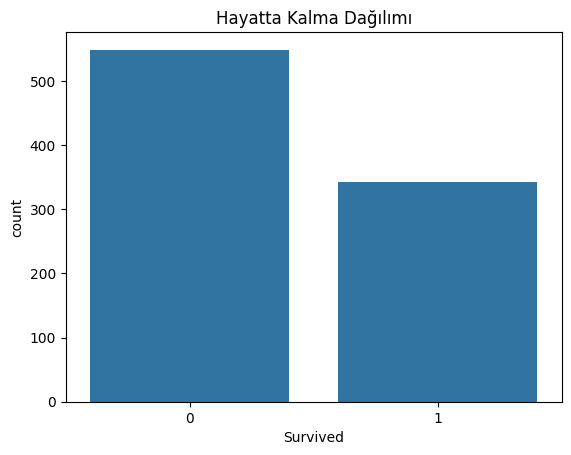

In [5]:
# Sayıları görelim
print(df["Survived"].value_counts())

# Görselleştirelim
sns.countplot(x="Survived", data=df)
plt.title("Hayatta Kalma Dağılımı")
plt.show()

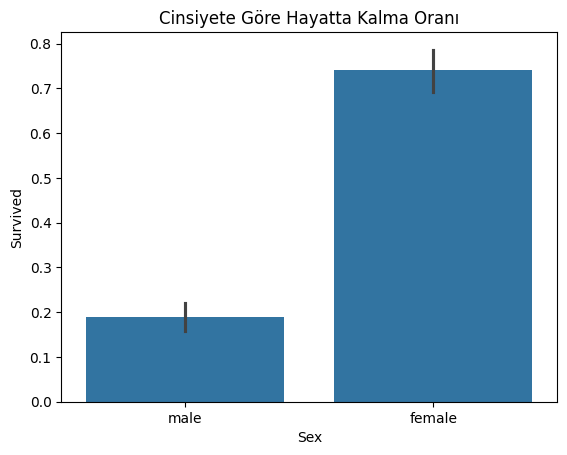

In [6]:
# Kadın ve erkeklerin hayatta kalma oranları
sns.barplot(x="Sex", y="Survived", data=df)
plt.title("Cinsiyete Göre Hayatta Kalma Oranı")
plt.show()

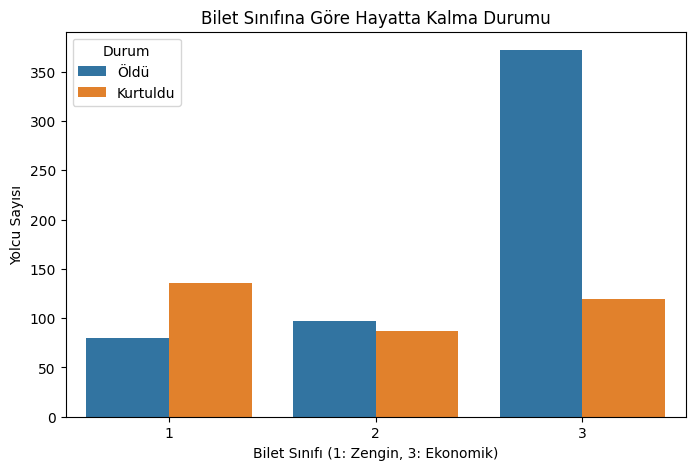

In [7]:
# 'Pclass' sütununa göre hayatta kalanları (1) ve ölenleri (0) saydırıp çizdiriyoruz.
# hue="Survived" komutu: "Bana sadece Pclass'ı çizme, her sınıfın içini 'Yaşayan/Ölen' diye iki renge ayır" demektir.

plt.figure(figsize=(8, 5))  # Grafiğin boyutunu ayarlıyoruz (Genişlik: 8, Yükseklik: 5)
sns.countplot(x="Pclass", hue="Survived", data=df)

plt.title("Bilet Sınıfına Göre Hayatta Kalma Durumu")
plt.xlabel("Bilet Sınıfı (1: Zengin, 3: Ekonomik)")
plt.ylabel("Yolcu Sayısı")
plt.legend(title="Durum", labels=["Öldü", "Kurtuldu"])
plt.show()

**Analiz 3: Sınıf Ayrımı Aşağıdaki grafikte görüldüğü üzere, 3. sınıf yolcuların ölüm oranı 1. sınıftakilere göre çok daha yüksektir. Bu durum, tahliye sırasında üst sınıflara öncelik tanındığını veya 3. sınıf kabinlerin güverteye uzak olduğunu düşündürmektedir.**


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


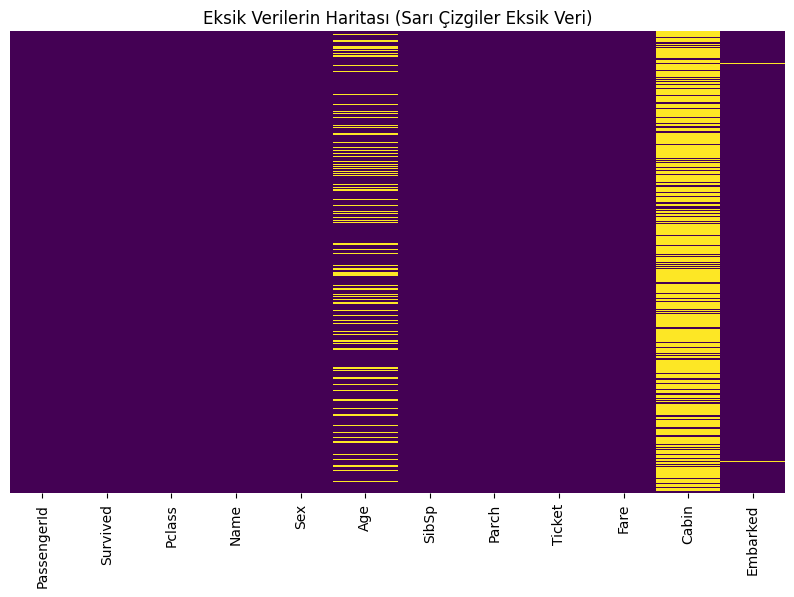

In [8]:
# Hangi sütunda kaç tane eksik (null/NaN) değer var?
# isnull(): "Boş mu?" diye sorar (Evet/Hayır döner).
# sum(): "Evet" diyenleri toplar.

print(df.isnull().sum())

# Bunu havalı bir harita (Heatmap) ile gösterelim (Github'da çok şık durur)
plt.figure(figsize=(10, 6))
# yticklabels=False: Y eksenindeki yüzlerce ismi yazma, kalabalık etmesin.
# cbar=False: Renk barını gösterme, gerek yok.
# cmap="viridis": Renk paleti (Mor-Sarı tonları genelde okunaklıdır).

sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap="viridis")
plt.title("Eksik Verilerin Haritası (Sarı Çizgiler Eksik Veri)")
plt.show()

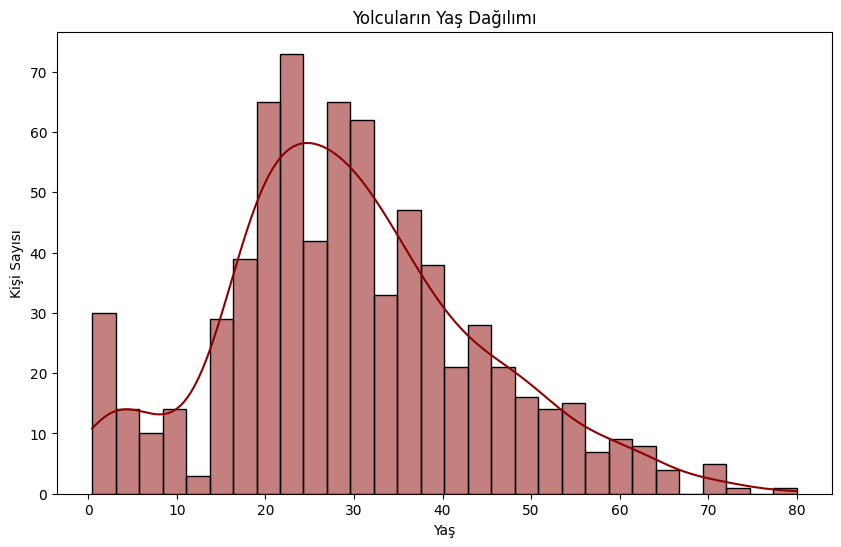

In [9]:
# Yaş dağılımını çizelim.
# dropna(): Eksik yaşları şimdilik görmezden gel, hata vermesin.
# bins=30: Yaşları 30 parçaya böl (0-2 yaş, 2-4 yaş gibi detaylı görelim).
# kde=True: Üzerine o meşhur "çan eğrisi" çizgisini ekle, dağılımı yumuşat.

plt.figure(figsize=(10, 6))
sns.histplot(df["Age"].dropna(), kde=True, bins=30, color="darkred")

plt.title("Yolcuların Yaş Dağılımı")
plt.xlabel("Yaş")
plt.ylabel("Kişi Sayısı")
plt.show()

/tmp/ipython-input-3025710227.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Pclass", y="Age", data=df, palette="winter")


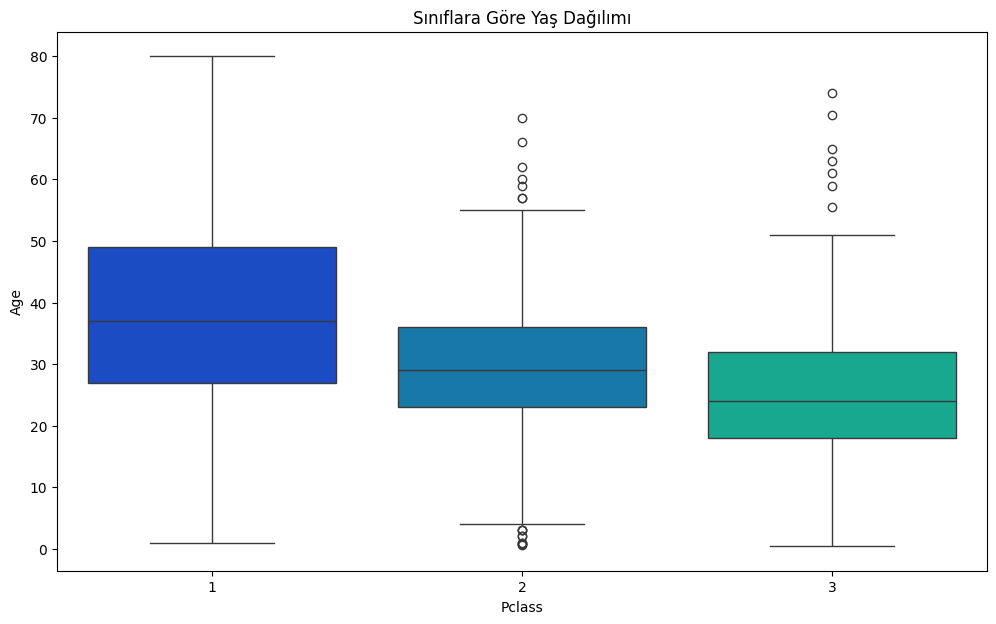

In [10]:
# Pclass (Sınıf) ile Age (Yaş) arasındaki ilişkiye bakalım.
# Boxplot: Ortalamayı ve yaş aralığını kutu şeklinde gösterir.

plt.figure(figsize=(12, 7))
sns.boxplot(x="Pclass", y="Age", data=df, palette="winter")

plt.title("Sınıflara Göre Yaş Dağılımı")
plt.show()

/tmp/ipython-input-965989545.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Age = cols[0]
/tmp/ipython-input-965989545.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Pclass = cols[1]


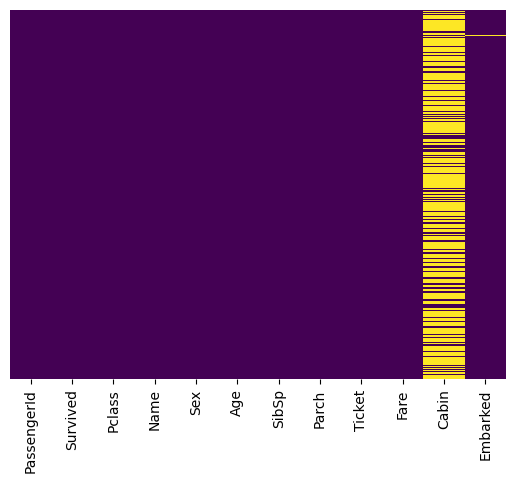

In [12]:
# Fonksiyonumuzu tanımlıyoruz
#"Not: Bu çalışmada eksik veriler, sınıfların yaş ortalaması ile doldurulmuştur (Mean Imputation). Bu durum veri setindeki varyansı düşürmüş olabilir.
#İlerleyen çalışmalarda standart sapma dikkate alınarak rastgele dağılım yöntemi kullanılabilir."

def eksik_yaslari_doldur(cols):
    Age = cols[0]
    Pclass = cols[1]

    if pd.isnull(Age): # Eğer yaş hücresi boşsa (NaN)
        if Pclass == 1:
            return 37 # 1. sınıf ortalaması
        elif Pclass == 2:
            return 29 # 2. sınıf ortalaması
        else:
            return 24 # 3. sınıf ortalaması
    else:
        return Age # Boş değilse kendi yaşını olduğu gibi bırak

# Şimdi bu fonksiyonu veri setine uyguluyoruz (Apply komutu)
# axis=1: Sütun sütun değil, satır satır işlem yap demek.
df["Age"] = df[["Age", "Pclass"]].apply(eksik_yaslari_doldur, axis=1)

# Kontrol edelim: Artık sarı çizgiler gitmiş olmalı!
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap="viridis")
plt.show()

In [13]:
# Cabin sütununda çok eksik var, kurtarılamaz -> Siliyoruz.
df.drop("Cabin", axis=1, inplace=True)

# Geriye kalan 1-2 tane ufak eksik varsa onları da satır bazında atalım.
df.dropna(inplace=True)

# Son durum: Tertemiz veri!
print(df.isnull().sum()) # Hepsi 0 çıkmalı.
print(df.head()) # Verinin son haline bir bakış.

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Embarked  
0      0         A/5 21171   7.2500        S  
1      0          PC 17599